In [16]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer import Aer
from qiskit import transpile

In [2]:
def create_grover_circuit(n_qubits, oracle_function):
    """
    Creates a Grover's algorithm circuit
    
    Parameters:
    n_qubits (int): Number of qubits in the system
    oracle_function: Function that implements the oracle for the specific problem
    """
    # Create quantum and classical registers
    qr = QuantumRegister(n_qubits, 'q')
    cr = ClassicalRegister(n_qubits, 'c')
    circuit = QuantumCircuit(qr, cr)
    
    # Step 1: Initialize in superposition
    for qubit in range(n_qubits):
        circuit.h(qubit)  # Apply Hadamard gates
    
    # Calculate number of iterations
    n_iterations = int(np.pi/4 * np.sqrt(2**n_qubits))
    
    for _ in range(n_iterations):
        # Step 2: Apply oracle
        oracle_function(circuit)
        
        # Step 3: Apply diffusion operator
        # 3a: Hadamard gates
        for qubit in range(n_qubits):
            circuit.h(qubit)
            
        # 3b: Multi-controlled Z gate (implemented as phase kickback)
        for qubit in range(n_qubits):
            circuit.x(qubit)
        
        # Multi-controlled Z
        circuit.h(n_qubits-1)
        circuit.mcx(list(range(n_qubits-1)), n_qubits-1)
        circuit.h(n_qubits-1)
        
        for qubit in range(n_qubits):
            circuit.x(qubit)
            
        # 3c: Hadamard gates
        for qubit in range(n_qubits):
            circuit.h(qubit)
    
    # Measurement
    circuit.measure(qr, cr)
    
    return circuit

# Example oracle for finding |11> state
def example_oracle(circuit):
    """Oracle that marks the |11> state"""
    circuit.cz(0, 1)  # Controlled-Z gate

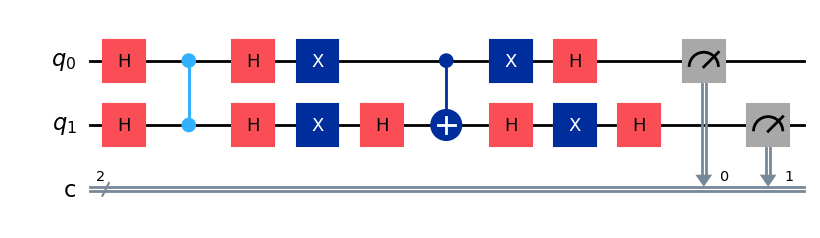

In [6]:
circuit = create_grover_circuit(2, example_oracle)
circuit.draw("mpl")

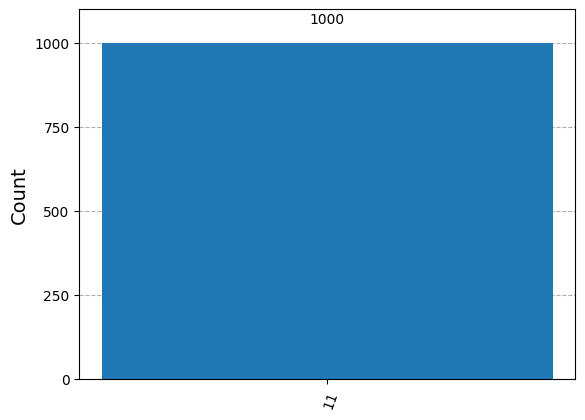

In [19]:
simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)